In [3]:
# Step 1: Setup and environment check
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import time

print("PyTorch version:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())
if torch.cuda.is_available():
    print("GPU name:", torch.cuda.get_device_name(0))
else:
    print("GPU not detected — training will only run on CPU.")


PyTorch version: 2.8.0+cu126
CUDA available: True
GPU name: Tesla T4


In [4]:
# Step 2: Load MNIST dataset
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))   # normalize pixels to [-1,1]
])

train_data = datasets.MNIST(root='data', train=True, transform=transform, download=True)
test_data = datasets.MNIST(root='data', train=False, transform=transform, download=True)

train_loader = DataLoader(train_data, batch_size=64, shuffle=True)
test_loader = DataLoader(test_data, batch_size=1000, shuffle=False)


In [5]:
# Step 3: Define a simple 3-layer fully connected neural network
class SimpleNN(nn.Module):
    def __init__(self):
        super(SimpleNN, self).__init__()
        self.fc1 = nn.Linear(28*28, 256)
        self.fc2 = nn.Linear(256, 128)
        self.fc3 = nn.Linear(128, 10)

    def forward(self, x):
        x = x.view(-1, 28*28)  # flatten input
        x = torch.relu(self.fc1(x))
        x = torch.relu(self.fc2(x))
        return self.fc3(x)


In [6]:
# Step 4: Train the model and record training time
def train_model(device, epochs=3):
    model = SimpleNN().to(device)
    optimizer = optim.Adam(model.parameters(), lr=0.001)
    criterion = nn.CrossEntropyLoss()

    start_time = time.time()
    for epoch in range(epochs):
        running_loss = 0.0
        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)

            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            running_loss += loss.item()
        print(f"Epoch [{epoch+1}/{epochs}] Loss: {running_loss/len(train_loader):.4f}")

    total_time = time.time() - start_time
    return total_time, model


In [7]:
# Step 5: Compare CPU and GPU training
cpu_device = torch.device("cpu")
gpu_device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("\n===== Training on CPU =====")
cpu_time, cpu_model = train_model(cpu_device)

if torch.cuda.is_available():
    print("\n===== Training on GPU =====")
    gpu_time, gpu_model = train_model(gpu_device)
else:
    gpu_time = None

# Compute Speedup
if gpu_time:
    speedup = cpu_time / gpu_time
    print(f"\n CPU time: {cpu_time:.2f}s")
    print(f" GPU time: {gpu_time:.2f}s")
    print(f" Speedup = {speedup:.2f}×")
else:
    print(f"\n CPU time: {cpu_time:.2f}s | GPU not available.")



===== Training on CPU =====
Epoch [1/3] Loss: 0.3418
Epoch [2/3] Loss: 0.1540
Epoch [3/3] Loss: 0.1137

===== Training on GPU =====
Epoch [1/3] Loss: 0.3361
Epoch [2/3] Loss: 0.1501
Epoch [3/3] Loss: 0.1125

 CPU time: 47.24s
 GPU time: 39.83s
 Speedup = 1.19×


In [8]:
# Step 6: Check GPU memory usage (optional)
if torch.cuda.is_available():
    print(f"Allocated GPU memory: {torch.cuda.memory_allocated() / 1024**2:.2f} MB")
    print(f"Reserved GPU memory: {torch.cuda.memory_reserved() / 1024**2:.2f} MB")


Allocated GPU memory: 19.72 MB
Reserved GPU memory: 138.00 MB


In [9]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
import time

# Define device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device in use:", device)

# Transform for MNIST
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

# Load dataset once
train_data = datasets.MNIST(root='data', train=True, transform=transform, download=True)
test_data = datasets.MNIST(root='data', train=False, transform=transform, download=True)


Device in use: cuda


In [10]:
class SimpleNN(nn.Module):
    def __init__(self):
        super(SimpleNN, self).__init__()
        self.fc1 = nn.Linear(28*28, 256)
        self.fc2 = nn.Linear(256, 128)
        self.fc3 = nn.Linear(128, 10)

    def forward(self, x):
        x = x.view(-1, 28*28)
        x = torch.relu(self.fc1(x))
        x = torch.relu(self.fc2(x))
        return self.fc3(x)


Using device: cuda

 Training with batch size = 16
Time: 18.26s | Accuracy: 94.46% | GPU Memory: 87.17 MB

 Training with batch size = 64
Time: 13.33s | Accuracy: 93.59% | GPU Memory: 87.17 MB

 Training with batch size = 256
Time: 11.79s | Accuracy: 90.74% | GPU Memory: 87.17 MB

 Training with batch size = 1024
Time: 11.68s | Accuracy: 88.58% | GPU Memory: 87.17 MB


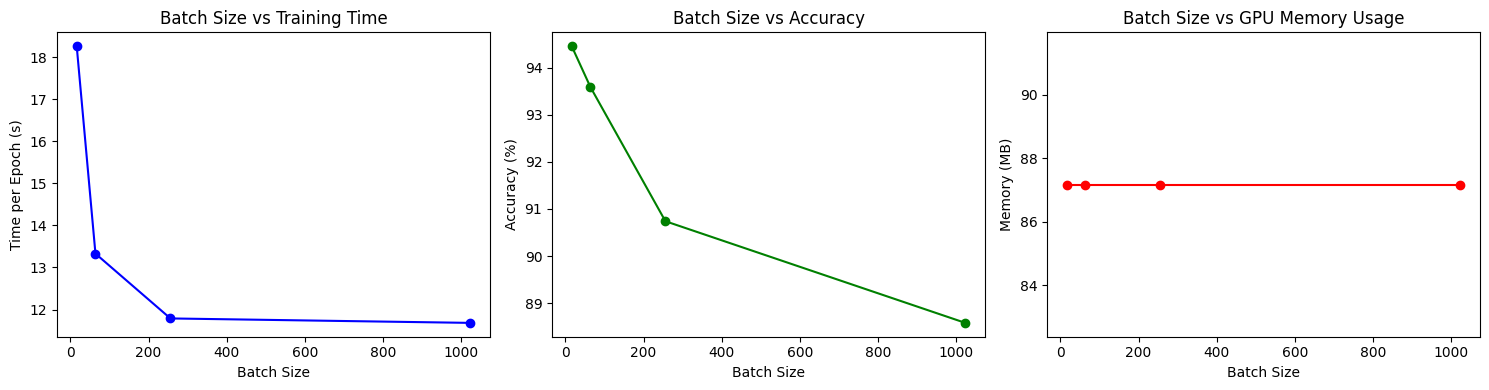

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
import torchvision
import torchvision.transforms as transforms
import time
import matplotlib.pyplot as plt


# 1 Setup

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

# Transform and load dataset (e.g., MNIST)
transform = transforms.Compose([transforms.ToTensor(), transforms.Normalize((0.5,), (0.5,))])
train_data = torchvision.datasets.MNIST(root='./data', train=True, download=True, transform=transform)
test_data = torchvision.datasets.MNIST(root='./data', train=False, download=True, transform=transform)


# 2 Simple Model Definition

class SimpleNN(nn.Module):
    def __init__(self):
        super(SimpleNN, self).__init__()
        self.fc1 = nn.Linear(28*28, 128)
        self.fc2 = nn.Linear(128, 64)
        self.fc3 = nn.Linear(64, 10)

    def forward(self, x):
        x = x.view(-1, 28*28)
        x = torch.relu(self.fc1(x))
        x = torch.relu(self.fc2(x))
        x = self.fc3(x)
        return x


# 3 Training and Evaluation

def train_one_epoch(model, train_loader, optimizer, criterion):
    model.train()
    running_loss = 0.0
    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        running_loss += loss.item()
    return running_loss / len(train_loader)

def evaluate(model, test_loader):
    model.eval()
    correct, total = 0, 0
    with torch.no_grad():
        for images, labels in test_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            _, predicted = torch.max(outputs, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
    return correct / total


# 4 Experiment — Batch Size Effect

batch_sizes = [16, 64, 256, 1024]
train_times, accuracies, gpu_memory = [], [], []
criterion = nn.CrossEntropyLoss()

for bs in batch_sizes:
    print(f"\n Training with batch size = {bs}")
    train_loader = DataLoader(train_data, batch_size=bs, shuffle=True)
    test_loader = DataLoader(test_data, batch_size=1000, shuffle=False)
    model = SimpleNN().to(device)
    optimizer = optim.Adam(model.parameters(), lr=0.001)

    start = time.time()
    train_one_epoch(model, train_loader, optimizer, criterion)
    end = time.time()

    acc = evaluate(model, test_loader)

    train_times.append(end - start)
    accuracies.append(acc)

    if torch.cuda.is_available():
        mem = torch.cuda.max_memory_allocated() / 1024**2  # in MB
        gpu_memory.append(mem)
        torch.cuda.empty_cache()
    else:
        gpu_memory.append(0)

    print(f"Time: {end - start:.2f}s | Accuracy: {acc*100:.2f}% | GPU Memory: {gpu_memory[-1]:.2f} MB")


# 5 Plot Results

plt.figure(figsize=(15, 4))

# Plot 1: Batch Size vs Training Time
plt.subplot(1, 3, 1)
plt.plot(batch_sizes, train_times, marker='o', color='blue')
plt.title("Batch Size vs Training Time")
plt.xlabel("Batch Size")
plt.ylabel("Time per Epoch (s)")

# Plot 2: Batch Size vs Accuracy
plt.subplot(1, 3, 2)
plt.plot(batch_sizes, [a*100 for a in accuracies], marker='o', color='green')
plt.title("Batch Size vs Accuracy")
plt.xlabel("Batch Size")
plt.ylabel("Accuracy (%)")

# Plot 3: Batch Size vs GPU Memory Usage
plt.subplot(1, 3, 3)
plt.plot(batch_sizes, gpu_memory, marker='o', color='red')
plt.title("Batch Size vs GPU Memory Usage")
plt.xlabel("Batch Size")
plt.ylabel("Memory (MB)")

plt.tight_layout()
plt.show()


In [12]:
# Step 1: Import essentials
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
import time

# Step 2: Device setup (CPU or GPU)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f" Using device: {device}")

# Step 3: Load MNIST dataset (same for all models)
transform = transforms.Compose([transforms.ToTensor(), transforms.Normalize((0.5,), (0.5,))])
trainset = torchvision.datasets.MNIST(root='./data', train=True, download=True, transform=transform)
trainloader = torch.utils.data.DataLoader(trainset, batch_size=64, shuffle=True)

# Step 4: Define 3 models (Small, Medium, Large)
class SmallModel(nn.Module):
    def __init__(self):
        super(SmallModel, self).__init__()
        self.fc = nn.Sequential(
            nn.Flatten(),
            nn.Linear(28*28, 128),
            nn.ReLU(),
            nn.Linear(128, 10)
        )
    def forward(self, x):
        return self.fc(x)

class MediumModel(nn.Module):
    def __init__(self):
        super(MediumModel, self).__init__()
        self.fc = nn.Sequential(
            nn.Flatten(),
            nn.Linear(28*28, 256),
            nn.ReLU(),
            nn.Linear(256, 128),
            nn.ReLU(),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Linear(64, 10)
        )
    def forward(self, x):
        return self.fc(x)

class LargeCNN(nn.Module):
    def __init__(self):
        super(LargeCNN, self).__init__()
        self.conv = nn.Sequential(
            nn.Conv2d(1, 32, 3, padding=1), nn.ReLU(), nn.MaxPool2d(2, 2),
            nn.Conv2d(32, 64, 3, padding=1), nn.ReLU(), nn.MaxPool2d(2, 2),
            nn.Conv2d(64, 128, 3, padding=1), nn.ReLU()
        )
        self.fc = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128*7*7, 256), nn.ReLU(),
            nn.Linear(256, 10)
        )
    def forward(self, x):
        x = self.conv(x)
        x = self.fc(x)
        return x

# Step 5: Training function (shared for all models)
def train_model(model, name, epochs=2):
    model.to(device)
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=0.001)

    start_time = time.time()
    for epoch in range(epochs):
        epoch_start = time.time()
        running_loss = 0.0
        for images, labels in trainloader:
            images, labels = images.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            running_loss += loss.item()

        epoch_time = time.time() - epoch_start
        print(f"[{name}] Epoch {epoch+1}/{epochs} - Loss: {running_loss/len(trainloader):.4f} - Time: {epoch_time:.2f}s")

    total_time = time.time() - start_time
    gpu_mem = torch.cuda.memory_allocated(device)/1e6 if device.type == 'cuda' else 0
    print(f" {name} | Total Time: {total_time:.2f}s | Peak GPU Memory: {gpu_mem:.2f} MB\n")
    return total_time, gpu_mem

# Step 6: Train all models
results = {}
for model_class, name in [(SmallModel, "Small"), (MediumModel, "Medium"), (LargeCNN, "Large CNN")]:
    print(f"\n Training {name} model...")
    model = model_class()
    total_time, gpu_mem = train_model(model, name)
    results[name] = (total_time, gpu_mem)

# Step 7: Print comparison summary
print("\n Summary (Model Complexity Comparison)")
print("Model\t\tTotal Time (s)\tGPU Memory (MB)")
for name, (time_taken, mem_used) in results.items():
    print(f"{name}\t\t{time_taken:.2f}\t\t{mem_used:.2f}")


 Using device: cuda

 Training Small model...
[Small] Epoch 1/2 - Loss: 0.3810 - Time: 12.95s
[Small] Epoch 2/2 - Loss: 0.1935 - Time: 13.09s
 Small | Total Time: 26.05s | Peak GPU Memory: 22.41 MB


 Training Medium model...
[Medium] Epoch 1/2 - Loss: 0.3770 - Time: 13.40s
[Medium] Epoch 2/2 - Loss: 0.1700 - Time: 13.52s
 Medium | Total Time: 26.93s | Peak GPU Memory: 24.66 MB


 Training Large CNN model...
[Large CNN] Epoch 1/2 - Loss: 0.1275 - Time: 15.35s
[Large CNN] Epoch 2/2 - Loss: 0.0399 - Time: 16.23s
 Large CNN | Total Time: 31.57s | Peak GPU Memory: 48.23 MB


 Summary (Model Complexity Comparison)
Model		Total Time (s)	GPU Memory (MB)
Small		26.05		22.41
Medium		26.93		24.66
Large CNN		31.57		48.23


In [13]:
# Step 1: Import required libraries
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
import time

# Step 2: Set device (CPU or GPU)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# Step 3: Define a simple dataset and model (same across all tests)
transform = transforms.Compose([transforms.ToTensor(), transforms.Normalize((0.5,), (0.5,))])
trainset = torchvision.datasets.MNIST(root='./data', train=True, download=True, transform=transform)

# Simple model to focus on data loading efficiency (not model complexity)
class SimpleModel(nn.Module):
    def __init__(self):
        super(SimpleModel, self).__init__()
        self.fc = nn.Sequential(
            nn.Flatten(),
            nn.Linear(28*28, 128),
            nn.ReLU(),
            nn.Linear(128, 10)
        )
    def forward(self, x):
        return self.fc(x)

# Step 4: Function to test different num_workers configurations
def test_dataloader_performance(num_workers):
    print(f"\nTesting DataLoader with num_workers = {num_workers}")

    # Initialize DataLoader
    trainloader = torch.utils.data.DataLoader(
        trainset,
        batch_size=128,
        shuffle=True,
        num_workers=num_workers,
        pin_memory=True  # Helps GPU load data faster
    )

    model = SimpleModel().to(device)
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=0.001)

    total_start = time.time()
    epoch_start = time.time()

    # Train for one epoch only (to measure loading time impact)
    for batch_idx, (images, labels) in enumerate(trainloader):
        batch_start = time.time()

        # Move data to device
        images, labels = images.to(device), labels.to(device)

        # Forward + backward pass
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        # Measure batch data loading time
        batch_time = time.time() - batch_start
        if batch_idx % 100 == 0:
            print(f"Batch {batch_idx} — Time per batch: {batch_time:.4f}s")

    epoch_time = time.time() - epoch_start
    total_time = time.time() - total_start
    print(f"num_workers = {num_workers} | Epoch Time: {epoch_time:.2f}s | Total Time: {total_time:.2f}s")

    # Measure GPU memory usage (optional)
    gpu_mem = torch.cuda.memory_allocated(device)/1e6 if device.type == 'cuda' else 0
    print(f"GPU Memory Usage: {gpu_mem:.2f} MB\n")

    return epoch_time, gpu_mem

# Step 5: Run tests for num_workers = 0, 2, 4, 8
results = {}
for workers in [0, 2, 4, 8]:
    epoch_time, gpu_mem = test_dataloader_performance(workers)
    results[workers] = (epoch_time, gpu_mem)

# Step 6: Summary of results
print("\nSummary: Data Loading Efficiency Comparison")
print("num_workers\tEpoch Time (s)\tGPU Memory (MB)")
for workers, (epoch_time, gpu_mem) in results.items():
    print(f"{workers}\t\t{epoch_time:.2f}\t\t{gpu_mem:.2f}")


Using device: cuda

Testing DataLoader with num_workers = 0
Batch 0 — Time per batch: 0.0021s
Batch 100 — Time per batch: 0.0016s
Batch 200 — Time per batch: 0.0015s
Batch 300 — Time per batch: 0.0015s
Batch 400 — Time per batch: 0.0019s
num_workers = 0 | Epoch Time: 12.43s | Total Time: 12.43s
GPU Memory Usage: 36.22 MB


Testing DataLoader with num_workers = 2
Batch 0 — Time per batch: 0.0090s
Batch 100 — Time per batch: 0.0022s
Batch 200 — Time per batch: 0.0019s
Batch 300 — Time per batch: 0.0029s
Batch 400 — Time per batch: 0.0043s
num_workers = 2 | Epoch Time: 11.02s | Total Time: 11.02s
GPU Memory Usage: 36.22 MB


Testing DataLoader with num_workers = 4


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:627: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  warnings.warn(


Batch 0 — Time per batch: 0.0185s
Batch 100 — Time per batch: 0.0079s
Batch 200 — Time per batch: 0.0060s
Batch 300 — Time per batch: 0.0052s
Batch 400 — Time per batch: 0.0085s
num_workers = 4 | Epoch Time: 11.24s | Total Time: 11.24s
GPU Memory Usage: 36.22 MB


Testing DataLoader with num_workers = 8


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:627: UserWarning: This DataLoader will create 8 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  warnings.warn(


Batch 0 — Time per batch: 0.0569s
Batch 100 — Time per batch: 0.0071s
Batch 200 — Time per batch: 0.0123s
Batch 300 — Time per batch: 0.0049s
Batch 400 — Time per batch: 0.0069s
num_workers = 8 | Epoch Time: 11.96s | Total Time: 11.96s
GPU Memory Usage: 36.22 MB


Summary: Data Loading Efficiency Comparison
num_workers	Epoch Time (s)	GPU Memory (MB)
0		12.43		36.22
2		11.02		36.22
4		11.24		36.22
8		11.96		36.22


In [2]:
# Step 1: Import required libraries
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
import time

# Step 2: Set device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# Step 3: Load dataset (MNIST)
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

trainset = torchvision.datasets.MNIST(root='./data', train=True, download=True, transform=transform)
trainloader = torch.utils.data.DataLoader(trainset, batch_size=256, shuffle=True, num_workers=2, pin_memory=True)

# Step 4: Define a small CNN model (same for both tests)
class SmallCNN(nn.Module):
    def __init__(self):
        super(SmallCNN, self).__init__()
        self.conv = nn.Sequential(
            nn.Conv2d(1, 16, 3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),
            nn.Conv2d(16, 32, 3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2, 2)
        )
        self.fc = nn.Sequential(
            nn.Flatten(),
            nn.Linear(32 * 7 * 7, 128),
            nn.ReLU(),
            nn.Linear(128, 10)
        )
    def forward(self, x):
        x = self.conv(x)
        x = self.fc(x)
        return x

# Step 5: Define training function (with and without AMP)
def train_model(use_amp=False):
    model = SmallCNN().to(device)
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=0.001)
    scaler = torch.cuda.amp.GradScaler(enabled=use_amp)  # Enables AMP if requested

    start_time = time.time()
    total_loss = 0.0

    print(f"\nTraining {'with' if use_amp else 'without'} AMP...")

    for epoch in range(1):
        for images, labels in trainloader:
            images, labels = images.to(device), labels.to(device)

            optimizer.zero_grad()

            # Forward + backward pass with optional mixed precision
            with torch.cuda.amp.autocast(enabled=use_amp):
                outputs = model(images)
                loss = criterion(outputs, labels)

            # Scale gradients only if AMP is used
            scaler.scale(loss).backward()
            scaler.step(optimizer)
            scaler.update()

            total_loss += loss.item()

    total_time = time.time() - start_time
    avg_loss = total_loss / len(trainloader)
    gpu_mem = torch.cuda.memory_allocated(device)/1e6 if device.type == 'cuda' else 0

    print(f"{'AMP' if use_amp else 'FP32'} Training Completed — Time: {total_time:.2f}s | Loss: {avg_loss:.4f} | GPU Memory: {gpu_mem:.2f} MB\n")
    return total_time, avg_loss, gpu_mem

# Step 6: Run both versions
time_fp32, loss_fp32, mem_fp32 = train_model(use_amp=False)
time_amp, loss_amp, mem_amp = train_model(use_amp=True)

# Step 7: Compare results
print("Performance Comparison:")
print("Mode\t\tTime (s)\tLoss\t\tGPU Memory (MB)")
print(f"FP32\t\t{time_fp32:.2f}\t\t{loss_fp32:.4f}\t\t{mem_fp32:.2f}")
print(f"AMP (FP16)\t{time_amp:.2f}\t\t{loss_amp:.4f}\t\t{mem_amp:.2f}")

# Step 8: Compute speedup
if time_amp > 0:
    speedup = time_fp32 / time_amp
    print(f"\nSpeedup from AMP: {speedup:.2f}x")



Using device: cuda

Training without AMP...


/tmp/ipython-input-3338578639.py:50: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler(enabled=use_amp)  # Enables AMP if requested
/tmp/ipython-input-3338578639.py:64: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=use_amp):


FP32 Training Completed — Time: 11.28s | Loss: 0.3741 | GPU Memory: 22.42 MB


Training with AMP...
AMP Training Completed — Time: 12.45s | Loss: 0.3961 | GPU Memory: 22.42 MB

Performance Comparison:
Mode		Time (s)	Loss		GPU Memory (MB)
FP32		11.28		0.3741		22.42
AMP (FP16)	12.45		0.3961		22.42

Speedup from AMP: 0.91x
